# Géron Ch. 1 — Life Satisfaction Practice

**Goal:** Explore the `lifesat` family of datasets, understand what each file
contains, and build intuition for GDP ↔ life-satisfaction relationships.

**Date:** 2026-04-18
**Source:** github.com/ageron/data/tree/main/lifesat

## Imports

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Setup — paths and constants

In [3]:
DATA_DIR = Path(".")    # current folder; change if data lives elsewhere
RANDOM_SEED = 42        # for reproducibility whenever we sample or shuffle

## Data Loading

In [7]:
lifesat = pd.read_csv(DATA_DIR / "lifesat.csv")
lifesat_full = pd.read_csv(DATA_DIR / "lifesat_full.csv")
gdp = pd.read_csv(DATA_DIR / "gdp_per_capita.csv")
oecd = pd.read_csv(DATA_DIR / "oecd_bli.csv")

## Data Exploration

In [8]:
lifesat.shape

(27, 3)

In [9]:
lifesat.head()

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6


In [10]:
lifesat.dtypes

Country                     str
GDP per capita (USD)    float64
Life satisfaction       float64
dtype: object

In [13]:
lifesat.describe(include="all")

,Country,GDP per capita (USD),Life satisfaction
count,27,27.000000,27.000000
unique,27,NaN,NaN
top,Russia,NaN,NaN
freq,1,NaN,NaN
mean,NaN,41564.521771,6.566667
std,NaN,9631.452319,0.765607
min,NaN,26456.387938,5.400000
25%,NaN,33938.289305,5.900000
50%,NaN,41627.129269,6.800000
75%,NaN,49690.580269,7.300000


In [14]:
lifesat.isna().sum()

Country                 0
GDP per capita (USD)    0
Life satisfaction       0
dtype: int64

In [25]:
lifesat['Country'].unique()

<StringArray>
[        'Russia',         'Greece',         'Turkey',         'Latvia',
        'Hungary',       'Portugal',         'Poland',        'Estonia',
          'Spain',       'Slovenia',      'Lithuania',         'Israel',
          'Italy', 'United Kingdom',         'France',    'New Zealand',
         'Canada',        'Finland',        'Belgium',      'Australia',
         'Sweden',        'Germany',        'Austria',        'Iceland',
    'Netherlands',        'Denmark',  'United States']
Length: 27, dtype: str

In [28]:
lifesat['GDP per capita (USD)'].max() - lifesat['GDP per capita (USD)'].min()

np.float64(33779.340553564805)

In [30]:
np.ptp(lifesat['GDP per capita (USD)']) 

np.float64(33779.340553564805)

In [31]:
lifesat['GDP per capita (USD)'].max() 

np.float64(60235.7284916969)

In [39]:
lifesat.sort_values(by='GDP per capita (USD)', ascending=False).iloc[0]

Country                 United States
GDP per capita (USD)     60235.728492
Life satisfaction                 6.9
Name: 26, dtype: object

In [40]:
lifesat.sort_values('GDP per capita (USD)', ascending=False).head(1)   # DataFrame (1 row)

,Country,GDP per capita (USD),Life satisfaction
26,United States,60235.728492,6.9


In [41]:
lifesat['GDP per capita (USD)'].idxmax()

26

In [42]:
lifesat.loc[lifesat['GDP per capita (USD)'].idxmin(), 'Country']

'Russia'

In [43]:
high_gdp = lifesat[lifesat['GDP per capita (USD)'] > 30000]
high_gdp

,Country,GDP per capita (USD),Life satisfaction
4,Hungary,31007.768407,5.6
5,Portugal,32181.154537,5.4
6,Poland,32238.157259,6.1
7,Estonia,35638.421351,5.7
8,Spain,36215.447591,6.3
9,Slovenia,36547.738956,5.9
10,Lithuania,36732.034744,5.9
11,Israel,38341.307570,7.2
12,Italy,38992.148381,6.0
13,United Kingdom,41627.129269,6.8


In [44]:
min_idx = high_gdp['Life satisfaction'].idxmin()
print(min_idx)

5


In [60]:
high_gdp.loc[min_idx, 'Country']

'Portugal'

In [61]:
high_gdp.iloc[0, 0]

'Hungary'

In [62]:
lifesat

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6
5,Portugal,32181.154537,5.4
6,Poland,32238.157259,6.1
7,Estonia,35638.421351,5.7
8,Spain,36215.447591,6.3
9,Slovenia,36547.738956,5.9


In [70]:
mx_LS_id=lifesat['Life satisfaction'].idxmax()
lifesat.loc[mx_LS_id,'Country']

'Finland'

In [72]:
lifesat.sort_values('Life satisfaction', ascending=False).head()

,Country,GDP per capita (USD),Life satisfaction
25,Denmark,55938.212809,7.6
17,Finland,47260.800458,7.6
23,Iceland,52279.728851,7.5
24,Netherlands,54209.563836,7.4
16,Canada,45856.625626,7.4


In [73]:
max_val = lifesat['Life satisfaction'].max()
lifesat[lifesat['Life satisfaction'] == max_val]

,Country,GDP per capita (USD),Life satisfaction
17,Finland,47260.800458,7.6
25,Denmark,55938.212809,7.6


In [74]:
lifesat.corr(numeric_only=True)

,GDP per capita (USD),Life satisfaction
GDP per capita (USD),1.000000,0.852796
Life satisfaction,0.852796,1.000000


In [80]:
lifesat['GDP per capita (USD)'].corr(lifesat['Life satisfaction'])

np.float64(0.85279604439002)

In [81]:
lifesat.corr(numeric_only=True, method='pearson')   # ~0.85
lifesat.corr(numeric_only=True, method='spearman')  # probably similar

,GDP per capita (USD),Life satisfaction
GDP per capita (USD),1.000000,0.844038
Life satisfaction,0.844038,1.000000


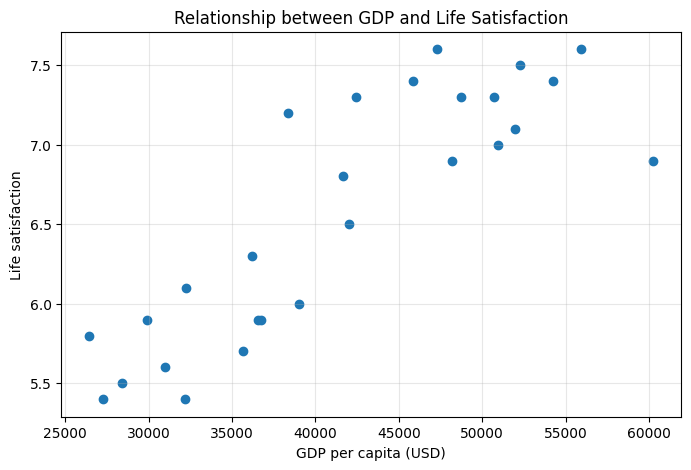

In [84]:
fig, ax = plt.subplots(figsize=(8, 5))   # create figure and axes
ax.scatter(lifesat['GDP per capita (USD)'], lifesat['Life satisfaction'])                         # plot
ax.set_xlabel('GDP per capita (USD)')              # x-axis label
ax.set_ylabel('Life satisfaction')                 # y-axis label
ax.set_title('Relationship between GDP and Life Satisfaction')  # title
ax.grid(True, alpha=0.3)                           # light gridlines
plt.show()                                         # render (optional in Jupyter but good habit)

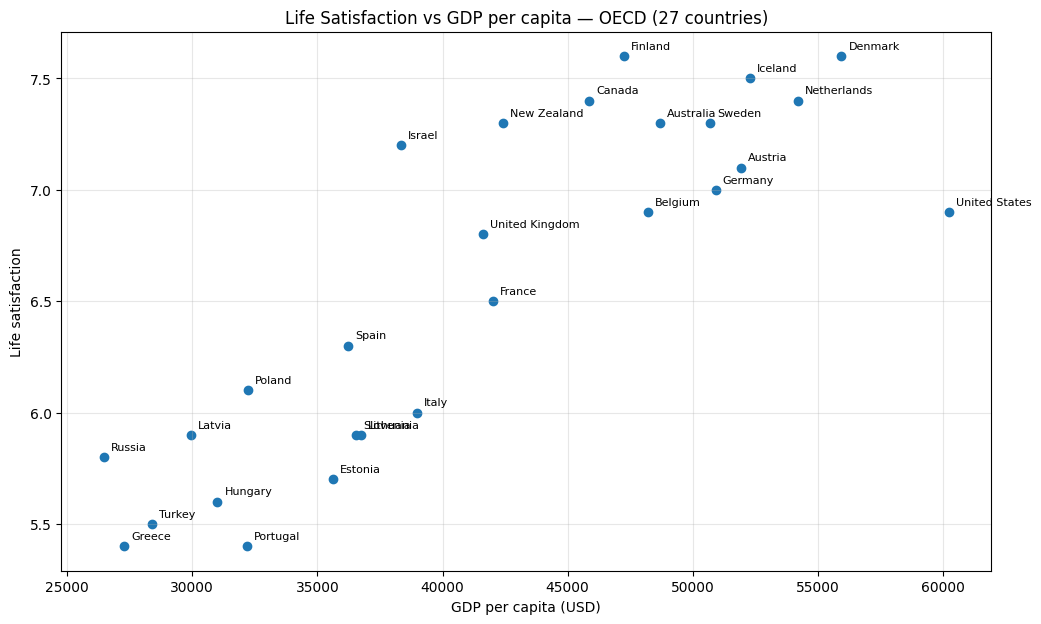

In [86]:
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter
ax.scatter(lifesat['GDP per capita (USD)'], lifesat['Life satisfaction'])

# Label every country
for _, row in lifesat.iterrows():
    ax.annotate(
        row['Country'],
        xy=(row['GDP per capita (USD)'], row['Life satisfaction']),
        xytext=(5, 5),                     # 5 px right, 5 px up from the dot
        textcoords='offset points',
        fontsize=8,
    )

# Cosmetics
ax.set_xlabel('GDP per capita (USD)')
ax.set_ylabel('Life satisfaction')
ax.set_title('Life Satisfaction vs GDP per capita — OECD (27 countries)')
ax.grid(True, alpha=0.3)
ax.ticklabel_format(style='plain', axis='x')   # no scientific notation on x-axis

plt.show()

In [88]:
oecd_bli=pd.read_csv(DATA_DIR / "oecd_bli.csv", thousands=',')


In [92]:
oecd_bli.head()
oecd_bli.info()

<class 'pandas.DataFrame'>
RangeIndex: 2369 entries, 0 to 2368
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   LOCATION               2369 non-null   str    
 1   Country                2369 non-null   str    
 2   INDICATOR              2369 non-null   str    
 3   Indicator              2369 non-null   str    
 4   MEASURE                2369 non-null   str    
 5   Measure                2369 non-null   str    
 6   INEQUALITY             2369 non-null   str    
 7   Inequality             2369 non-null   str    
 8   Unit Code              2369 non-null   str    
 9   Unit                   2369 non-null   str    
 10  PowerCode Code         2369 non-null   int64  
 11  PowerCode              2369 non-null   str    
 12  Reference Period Code  0 non-null      float64
 13  Reference Period       0 non-null      float64
 14  Value                  2369 non-null   float64
 15  Flag Codes     

In [94]:
oecd_bli['Value'].describe()

count      2369.000000
mean       4563.698442
std       36765.671499
min           0.000000
25%           6.780000
50%          58.400000
75%          85.000000
max      769053.000000
Name: Value, dtype: float64

In [95]:
oecd_bli.loc[oecd_bli['Value'] == oecd_bli['Value'].max(), ['LOCATION', 'Country', 'Indicator']]

,LOCATION,Country,Indicator
468,LUX,Luxembourg,Household net wealth


In [96]:
oecd_bli.isna().sum()

LOCATION                    0
Country                     0
INDICATOR                   0
Indicator                   0
MEASURE                     0
Measure                     0
INEQUALITY                  0
Inequality                  0
Unit Code                   0
Unit                        0
PowerCode Code              0
PowerCode                   0
Reference Period Code    2369
Reference Period         2369
Value                       0
Flag Codes               2369
Flags                    2369
dtype: int64

In [97]:
oecd=oecd_bli

In [99]:
oecd.columns.to_list()
oecd.dtypes

LOCATION                     str
Country                      str
INDICATOR                    str
Indicator                    str
MEASURE                      str
Measure                      str
INEQUALITY                   str
Inequality                   str
Unit Code                    str
Unit                         str
PowerCode Code             int64
PowerCode                    str
Reference Period Code    float64
Reference Period         float64
Value                    float64
Flag Codes               float64
Flags                    float64
dtype: object

In [100]:
oecd['Indicator'].value_counts()

Indicator
Student skills                                       200
Self-reported health                                 182
Quality of support network                           168
Life satisfaction                                    168
Labour market insecurity                             162
Feeling safe walking alone at night                  123
Employment rate                                      123
Water quality                                        123
Life expectancy                                      123
Homicide rate                                        123
Educational attainment                               120
Years in education                                   120
Long-term unemployment rate                          117
Employees working very long hours                    117
Time devoted to leisure and personal care             69
Air pollution                                         41
Voter turnout                                         41
Stakeholder engagemen

In [106]:
oecd[['Indicator', 'INEQUALITY', 'Inequality']].drop_duplicates()

,Indicator,INEQUALITY,Inequality
0,Labour market insecurity,TOT,Total
34,Labour market insecurity,MN,Men
66,Labour market insecurity,WMN,Women
98,Labour market insecurity,HGH,High
130,Labour market insecurity,LW,Low
...,...,...,...
2127,Employees working very long hours,MN,Men
2164,Employees working very long hours,WMN,Women
2201,Time devoted to leisure and personal care,TOT,Total
2224,Time devoted to leisure and personal care,MN,Men


In [107]:
oecd[(oecd['Country'] == 'Luxembourg') & (oecd['Indicator'] == 'Life expectancy')]['Value']

1535    82.8
1574    80.1
1613    85.4
Name: Value, dtype: float64

In [111]:
target_country = 'Luxembourg'
oecd.query("Country == @target_country and Indicator == 'Life expectancy' and Inequality == 'Total'")


,LOCATION,Country,INDICATOR,Indicator,MEASURE,Measure,INEQUALITY,Inequality,Unit Code,Unit,PowerCode Code,PowerCode,Reference Period Code,Reference Period,Value,Flag Codes,Flags
1535,LUX,Luxembourg,HS_LEB,Life expectancy,L,Value,TOT,Total,YR,Years,0,Units,NaN,NaN,82.8,NaN,NaN


In [112]:
lifesat.query("`GDP per capita (USD)` > 50000")

,Country,GDP per capita (USD),Life satisfaction
20,Sweden,50683.323510,7.3
21,Germany,50922.358023,7.0
22,Austria,51935.603862,7.1
23,Iceland,52279.728851,7.5
24,Netherlands,54209.563836,7.4
25,Denmark,55938.212809,7.6
26,United States,60235.728492,6.9


In [116]:
lifesat.query("`Life satisfaction` > 6 and `Life satisfaction` < 7")['Country']

6             Poland
8              Spain
13    United Kingdom
14            France
18           Belgium
26     United States
Name: Country, dtype: str

In [117]:
lifesat.query("`GDP per capita (USD)` > 40000 and `Life satisfaction` > 7")['Country']

15    New Zealand
16         Canada
17        Finland
19      Australia
20         Sweden
22        Austria
23        Iceland
24    Netherlands
25        Denmark
Name: Country, dtype: str